In [ ]:
import matplotlib
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import ConnectionPatch

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

def visualize_qps(csv_path: Path,
                  df_decode: pd.DataFrame, 
                  df_prefill: pd.DataFrame, 
                  time_bucket_ms: int = 10000, 
                  save_name: str = None, 
                  start_time: int = 0,
                  end_time: int = 5 * 60, ):
    """
    Generate a plot showing QPS for the first 35 minutes from an LLM inference request trace.
    """
    # Read the CSV
    df = pd.read_csv(csv_path)

    # Convert arrived_at to microseconds relative to first request
    df = df[(df['arrived_at'] >= start_time) & (df['arrived_at'] <= end_time)]
    df['timestamp_us'] = (df['arrived_at'] - start_time) * 1e6

    # Compute time bucket for each row
    df['time_bucket'] = (df['timestamp_us'] // (time_bucket_ms * 1000)).astype(int)

    # Aggregate QPS
    agg = df.groupby('time_bucket').agg(
        qps=('timestamp_us', 'count'),
        tps=('num_decode_tokens', 'sum')
    ).reset_index()


    # Fill in missing time buckets with zeroes
    all_buckets = pd.DataFrame({
        'time_bucket': np.arange(df['time_bucket'].min(), df['time_bucket'].max() + 1)
    })
    agg = pd.merge(all_buckets, agg, on='time_bucket', how='left').fillna(0)

    agg['qps'] = agg['qps'] / (time_bucket_ms / 1000.0)
    agg['tps'] = agg['tps'] / (time_bucket_ms / 1000.0)
    # Filter data for the first 35 minutes
    max_time_bucket = end_time 
    agg = agg[agg['time_bucket'] <= max_time_bucket]



    # Create a figure with two subplots in a single column
    fig, axes = plt.subplots(3, 1, figsize=(6, 5), constrained_layout=True, sharex=True)

    # sns.set_theme(context="paper", style="whitegrid")

    sns.lineplot(x=agg['time_bucket'] * (time_bucket_ms / 1000.0) / 60, y=agg['qps'], ax=axes[0], linewidth=2)
    axes[0].set_ylabel('RPS', fontsize=16)
    axes[0].set_ylim(0, 100)
    axes[0].tick_params(axis='both', which='major', labelsize=14)

    sns.lineplot(x=df_prefill['Timestamp'] / 60, y=df_prefill['run_q'], ax=axes[1], linewidth=2)
    axes[1].set_ylabel('Batch Size\nPrefill', fontsize=16)
    axes[1].tick_params(axis='both', which='major', labelsize=14)
    axes[1].set_ylim(0, 20)

    sns.lineplot(x=df_decode['Timestamp'] / 60, y=df_decode['run_q'], ax=axes[2], linewidth=2)
    axes[2].set_ylabel('Batch Size\nDecode', fontsize=16)
    axes[2].tick_params(axis='both', which='major', labelsize=14)
    axes[2].set_ylim(0, 900)

    axes[2].set_xlabel('Time (minutes)', fontsize=16)
    axes[2].set_xlim(0, 4)
    # Disable grid for all subplots
    for ax in axes:
        ax.grid(False)
    # # Add a single legend at the top
    # handles = [
    #     plt.Line2D([], [], color='blue', linestyle='-', linewidth=4, label='Min Energy'),
    #     plt.Line2D([], [], color='orange', linestyle='-', linewidth=4, label='BiScale')
    # ]
    # fig.legend(handles=handles, loc='upper center', fontsize=14, ncol=2, bbox_to_anchor=(0.6, 1.02))


    # Show the plots
    plt.show()

    # # Save the figure if save_name is provided
    if save_name:
        fig.savefig(save_name, format="pdf")

def get_combined_df_prefill(power_csv_paths: list[Path]) -> pd.DataFrame:
    run_q_df = None
    for i, path in enumerate(power_csv_paths):
        stats_df = pd.read_csv(path / "engine_0.csv")
        stats_df['time_to_first_tokens_iter_evald'] = stats_df['time_to_first_tokens_iter'].apply(eval)
        stats_df['ttft'] = stats_df['time_to_first_tokens_iter_evald'].apply(lambda x: np.max(x) if len(x) > 0 else 0)
        stats_df['num_prompt_tokens_reqs_evald'] = stats_df['num_prompt_tokens_reqs'].apply(eval)
        stats_df['num_running_reqs'] = stats_df['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x))
        if run_q_df is None:
            run_q_df = stats_df[['now', 'num_running_reqs', 'ttft']].copy()
        else:
            run_q_df = pd.merge_asof(run_q_df.sort_values('now'), 
                                        stats_df[['now', 'num_running_reqs', 'ttft']].sort_values('now'), 
                                        on='now', 
                                        direction='nearest', suffixes=(f'_x{i}', f'_y{i}'))
    run_q_df['run_q'] = run_q_df['num_running_reqs_x1'] + run_q_df['num_running_reqs_y1']# + run_q_df['num_running_reqs_x3'] + run_q_df['num_running_reqs_y3']
    run_q_df["Timestamp"] = run_q_df["now"] - run_q_df["now"].min()

    return run_q_df

def get_combined_df_decode(power_csv_paths: list[Path]) -> pd.DataFrame:
    run_q_df = None
    for path in power_csv_paths:
        stats_df = pd.read_csv(path / "engine_0.csv")
        stats_df['inter_token_latencies_iter_evald'] = stats_df['inter_token_latencies_iter'].apply(eval)
        stats_df['tpot'] = stats_df['inter_token_latencies_iter_evald'].apply(lambda x: np.median(x) if len(x) > 0 else 0)
        stats_df['run_q'] = stats_df['num_running_reqs']
        if run_q_df is None:
            run_q_df = stats_df[['now', 'run_q', 'tpot']].copy()
        # else:
        #     run_q_df = pd.merge_asof(run_q_df.sort_values('now'), 
        #                                 stats_df[['now', 'num_running_reqs', 'tpot']].sort_values('now'), 
        #                                 on='now', 
        #                                 direction='nearest')
        #     run_q_df['run_q'] = run_q_df['num_running_reqs_x'] + run_q_df['num_running_reqs_y']
        #     run_q_df = run_q_df.drop(columns=['num_running_reqs_x', 'num_running_reqs_y'])
    
    run_q_df["Timestamp"] = run_q_df["now"] - run_q_df["now"].min()

    return run_q_df

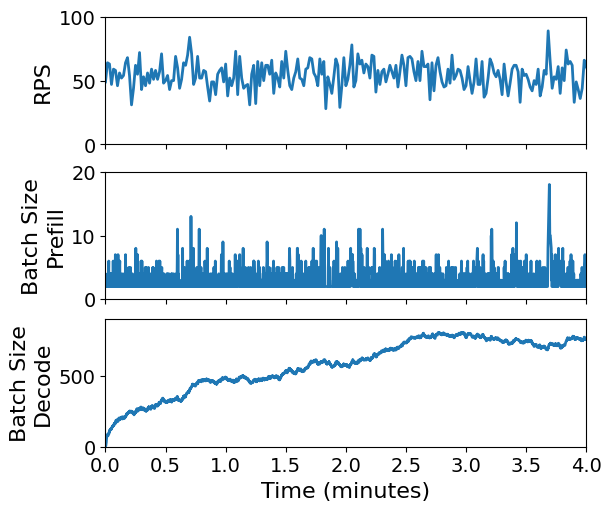

In [15]:
df_decode = get_combined_df_decode([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/synthetic_char_balance/DISTSERVE_R5_JAN3_B5_3/decode_4_Jan05011825'),])
df_prefill = get_combined_df_prefill([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/synthetic_char_balance/DISTSERVE_R5_JAN3_B5_3/prefill_0_Jan05011822_gpu1'),
                                      Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/synthetic_char_balance/DISTSERVE_R5_JAN3_B5_3/prefill_0_Jan05011825'),
                                      Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/synthetic_char_balance/DISTSERVE_R5_JAN3_B5_3/prefill_2_Jan05011825'),])
visualize_qps(csv_path=Path('trace_seed1k_rps55_5min.csv'), 
              df_decode=df_decode,
              df_prefill=df_prefill,
              time_bucket_ms=1000, 
              save_name="figs/rps_batch_size.pdf",
              start_time=0 * 60,
              end_time=5 * 60)